# Isaac Sim Jupyter Notebook Tutorial

This notebook will demonstrate step by step how to load the IAI apartment and a robot into the simulation environment.
 
> Select the jupyter kernel `Isaac Sim Python 3.11` if you are running in VScode.
>
> "Control + Enter" to execute the selected code cell. 

<!-- <button data-commandlinker-command="notebook:restart" class="jupyter-button">Force Stop</button> -->

## Start the GPU monitor and virtual desktop

Make sure the GPU has at least 3000M free memory.

If the virtual desktop does not pop up, manually click the "Open Desktop in new Tab".

In [1]:
from IPython import get_ipython
in_notebook = get_ipython().__class__.__name__ == "ZMQInteractiveShell"

from utils import *

# only runs in Jupyter Notebook
if in_notebook:
    from gpu_monitor import GPUMonitor
    # Monitor GPU usage
    gpu_monitor = GPUMonitor()
    # Open Desktop in sidecar
    display_desktop()

rclpy not installed! Have you source ROS2 environment?


HTML(value='')

HTML(value='<a href="/desktop"  class="jupyter-button" style="color: #fff;background-color: #1976d2;" target="…

## Start SimulationApp

The application window is frozen and non-interactive, which is normal.

<div style="color:red">This will take some time, so give it a minute and wait for it to say <b>"SimulationApp Ready!"</b> before you go to next step.</div>

In [1]:
from isaacsim import SimulationApp
from IPython.display import clear_output
import sys
import builtins

in_notebook = get_ipython().__class__.__name__ == "ZMQInteractiveShell"
original_stdout = sys.stdout
original_stderr = sys.stderr

simulation_app = SimulationApp({
    "headless": False,
    # "hide_ui": True,
    "width": 1280,
    "height": 960,
    "renderer": "RaytracedLighting",
    "display_options": 3286,  # Setsimulation_app.update() display options to show default grid
})

# Fix the issue where notebook output is being hijacked by Isaac Sim.
sys.stdout = original_stdout
sys.stderr = original_stderr
clear_output(wait=True)
print('SimulationApp Ready!')

SimulationApp Ready!


## Create a simulation environment

Setting physics to update at 200 Hz, rendering at 25 Hz, and using meters as the unit scale.

In [2]:
from isaacsim.core.api import World
from isaacsim.core.utils.prims import define_prim
from isaacsim.storage.native import get_assets_root_path

from isaacsim.core.utils.extensions import enable_extension
enable_extension("omni.physx.supportui")
enable_extension("isaacsim.ros2.bridge")

my_world = World(stage_units_in_meters=1.0,
                 physics_dt=1 / 200,
                 rendering_dt=8 / 200)
my_world.reset()

assets_root_path = get_assets_root_path()
prim = define_prim("/World/Ground", "Xform")
asset_path = assets_root_path + "/Isaac/Environments/Grid/default_environment.usd"
prim.GetReferences().AddReference(asset_path)

set 0: [SimpleListItem]: 1.0: 1.0, <omni.ui._ui.SimpleFloatModel object at 0x7a47fe3fcfb0>, [1.0, 0.6000000238418579, 0.0, 1.0]
set 1: [SimpleListItem]: 0.6: 0.6, <omni.ui._ui.SimpleFloatModel object at 0x7a47fe3b6330>, [1.0, 0.6000000238418579, 0.0, 1.0]
set 2: [SimpleListItem]: 0.0: 0.0, <omni.ui._ui.SimpleFloatModel object at 0x7a47fe3fcdf0>, [1.0, 0.6000000238418579, 0.0, 1.0]
set 3: [SimpleListItem]: 1.0: 1.0, <omni.ui._ui.SimpleFloatModel object at 0x7a47fe3fce30>, [1.0, 0.6000000238418579, 0.0, 1.0]


True

## Refresh View

Create a helper function to step the simulation world and update view. For the later code cells, wait for the progress bar to complete before proceeding to the next step.

In [3]:
from tqdm import tqdm

def refresh_view(steps=10, desc="World Stepping"):
    bar_format = "{l_bar}{bar}| {n_fmt}/{total_fmt} steps] {elapsed_s:.2f}s"
    for i in tqdm(range(steps), desc=desc, ncols=60, bar_format=bar_format, file=sys.stdout):
        my_world.step(render=True)

refresh_view()

World Stepping:   0%|                    | 0/10 steps] 0.00s[8.818s] Simulation App Startup Complete
[16.899s] [ext: omni.debugdraw-0.1.4] startup
[16.908s] [ext: omni.kit.widget.layers-1.8.6] startup
[16.971s] [ext: omni.usdphysics.ui-107.3.26] startup
[16.999s] [ext: omni.physx.commands-107.3.26] startup
[17.004s] [ext: omni.physx.ui-107.3.26] startup
[17.211s] [ext: omni.physx.supportui-107.3.26] startup
[17.281s] [ext: isaacsim.ros2.bridge-4.12.4] startup
[17.327s] Attempting to load system rclpy
[17.327s] Could not import system rclpy: No module named 'rclpy'
[17.327s] Attempting to load internal rclpy for ROS Distro: jazzy
[17.346s] rclpy loaded
World Stepping: 100%|███████████████████| 10/10 steps] 1.18s


## Spawn Apartment USD to the world

Asset Source:
https://github.com/Multiverse-Framework/Multiverse-Tutorials/tree/main/resources/apartmentICRA_full/usda

In [4]:
import os
import numpy as np
from isaacsim.core.utils.prims import create_prim
from isaacsim.core.utils import viewports

env_usd_path = f"{os.getcwd()}/../usd/apartment/apartmentICRA.usda"

create_prim(
    usd_path=env_usd_path,
    prim_path=f"/World/Apartment",
    position=np.array([-6, 5, 0.0701]),
    # orientation=np.array([0, 0, 0, 1])
)

viewports.set_camera_view(eye=np.array([-15, 0, 1.5]), 
                          target=np.array([0, 0, 0.5]))

refresh_view(steps=30, desc="Spawn Apartment")

Spawn Apartment: 100%|██████████████████| 30/30 steps] 1.20s


## Add lights

In [5]:
from isaacsim.core.utils.prims import create_prim

for i in range(1,4):
    gap = 4
    create_prim(
        prim_path=f"/World/Ground/Light_{i}",
        prim_type="SphereLight",
        attributes={"inputs:intensity": 10000},
        position=(-gap * i, 0, 2)
    )
    refresh_view(steps=10, desc="Add Lights")

Add Lights: 100%|███████████████████████| 10/10 steps] 0.25s
Add Lights: 100%|███████████████████████| 10/10 steps] 0.24s
Add Lights: 100%|███████████████████████| 10/10 steps] 0.24s


## Move Viewport Camera

In [6]:
import numpy as np
from isaacsim.core.utils import viewports
from omni.kit.viewport.utility.camera_state import ViewportCameraState

def move_camera(position, target, steps=100, smooth=True):
    end_pos = np.array(position)
    end_target = np.array(target)

    if smooth:
        # get current camera state
        cam_state = ViewportCameraState()
        start_pos = np.asarray(cam_state.position_world, dtype=np.double)
        start_target = np.asarray(cam_state.target_world, dtype=np.double)
        offset_pos = (end_pos - start_pos) / steps
        offset_target = (end_target - start_target) / steps
        for i in tqdm(range(steps), desc="Move Camera", file=sys.stdout):
            viewports.set_camera_view(eye=start_pos + offset_pos * i, 
                                      target=start_target + offset_target * i )
            my_world.step(render=True)
    else:
        viewports.set_camera_view(eye=end_pos, target=end_target)
    
    refresh_view(steps=10)

# move_camera(position=[-7, -2, 2], target=[-1, 1, 1], steps=50)

## Spawn Robots

In [7]:
import os
import numpy as np
from isaacsim.core.utils.prims import create_prim

# IAI robots
robots = [
    "stretch",
    "pr2",
    "hsrb",
    "tiago_dual",
]

for i in range(len(robots)):
    robot = robots[i]
    create_prim(
        usd_path=f"{os.getcwd()}/../usd/{robot}/{robot}.usd",
        prim_path=f"/World/{robot}",
        position=np.array([-i * 3 - 1, 0, 0.05]),
        orientation=np.array([0, 0, 0, 1])
    )
    refresh_view(steps=30, desc=f"Spawn {robot}")

Spawn stretch:  80%|████████████████    | 24/30 steps] 0.83s2026-01-28T11:43:45Z [168,293ms] [Warning] [omni.fabric.plugin] getAttributeCount called on non-existent path /World/stretch/base_link/collisions/mesh_1
2026-01-28T11:43:45Z [168,293ms] [Warning] [omni.fabric.plugin] getTypes called on non-existent path /World/stretch/base_link/collisions/mesh_1
Spawn stretch: 100%|████████████████████| 30/30 steps] 0.98s
Spawn pr2: 100%|████████████████████████| 30/30 steps] 0.88s
2026-01-28T11:43:46Z [169,371ms] [Warning] [carb] Client gpu.foundation.plugin has acquired [gpu::unstable::IMemoryBudgetManagerFactory v0.1] 100 times. Consider accessing this interface with carb::getCachedInterface() (Performance warning)
2026-01-28T11:43:47Z [170,121ms] [Warning] [omni.usd] Warning: in _ReportErrors at line 3172 of /builds/omniverse/usd-ci/USD/pxr/usd/usd/stage.cpp -- In </World/hsrb/hsrb/visuals>: Unresolved reference prim path @/home/jovyan/work/usd/hsrb/configuration/hsrb_physics.usd@</visuals

## Delete Robots

In [8]:
from isaacsim.core.utils.prims import delete_prim

# for i in range(len(robots)):
#     robot = robots[i]
#     delete_prim(f"/World/{robot}")
#     refresh_view(steps=10, desc=f"Delete {robot}")

## Create Robots Articulations

In [9]:
from isaacsim.core.prims import Articulation

robot_arts = {}

for robot in robots:
    robot_arts[robot] = Articulation(prim_paths_expr=f"/World/{robot}", name=f"my_{robot}")

## Get Joint Info

In [10]:
import pandas as pd

def get_joint_info(robot_art):
    joint_names = robot_art.dof_names
    joint_num = robot_art.num_dof
    joint_types = robot_art.get_dof_types()
    joint_limits = robot_art.get_dof_limits()[0]
    joint_states = robot_art.get_joint_positions()[0]
    
    df = pd.DataFrame({
        "Joint Name": joint_names,
        "Current Position": joint_states,
        "Lower Limit": [lim[0] for lim in joint_limits],
        "Upper Limit": [lim[1] for lim in joint_limits],
        "Type": joint_types,
    })
    
    unlimited = 3e38
    df["Lower Limit"] = df["Lower Limit"].mask(df["Lower Limit"] < -unlimited, -np.inf)
    df["Upper Limit"] = df["Upper Limit"].mask(df["Upper Limit"] > unlimited, np.inf)
    return df

if in_notebook:
    display(get_joint_info(robot_arts["stretch"]).style.format({
        "Lower Limit": "{:.8f}",
        "Upper Limit": "{:.8f}",
        "Current Position": "{:.8f}"
    }))

,Joint Name,Current Position,Lower Limit,Upper Limit,Type
0,joint_head_pan,0.00000601,-3.89999986,1.49999988,DofType.Rotation
1,joint_left_wheel,-0.00447560,-inf,inf,DofType.Rotation
2,joint_lift,0.00000000,0.00000000,1.10000002,DofType.Translation
3,joint_right_wheel,-0.00251485,-inf,inf,DofType.Rotation
4,joint_head_tilt,-0.00012732,-1.52999985,0.78999996,DofType.Rotation
5,joint_arm_l3,0.00006165,0.00000000,0.13000000,DofType.Translation
6,joint_arm_l2,0.00005929,0.00000000,0.13000000,DofType.Translation
7,joint_arm_l1,0.00006579,0.00000000,0.13000000,DofType.Translation
8,joint_arm_l0,0.00006149,0.00000000,0.13000000,DofType.Translation
9,joint_wrist_yaw,0.00000124,-1.74999988,3.99999976,DofType.Rotation


## Low Level Joint Control

In [11]:
def set_joint_pos(
    robot_art,
    joint_pos: dict = None,
    teleport: bool = False,
    max_steps: int = 100,
    threshold: float = 0.01
) -> dict:
    """
    Set target joint positions for a robot Articulation.

    Args:
        robot_art: Isaac Sim ArticulationView or similar class
        joint_pos (dict): {joint_name: target_position}
        teleport (bool): If True, instantly set joint positions
        max_steps (int): Maximum simulation steps to wait
        threshold (float): Required closeness between current and target joint positions

    Returns:
        dict: {
            "success": bool,
            "steps_used": int | None,
            "report": DataFrame | None,
            "message": str
        }
    """
    if joint_pos is None:
        joint_pos = {}

    joint_limits = robot_art.get_dof_limits()[0]
    joint_names = np.array(robot_art.dof_names)
    target_joint_pos = robot_art.get_joint_positions()[0].copy()

    # --- Apply limits and fill in target positions ---
    for name, value in joint_pos.items():
        idx = robot_art.get_dof_index(name)
        lower, upper = joint_limits[idx]
        clamped = np.clip(value, lower, upper)
        target_joint_pos[idx] = clamped

    # --- Instant teleport mode ---
    if teleport:
        robot_art.set_joint_positions([target_joint_pos])
        refresh_view(steps=10, desc="Teleport joints to target position")
        return {
            "success": True,
            "steps_used": 0,
            "report": None,
            "message": "Joints teleported successfully."
        }

    # --- Motion mode: send targets ---
    robot_art.set_joint_position_targets([target_joint_pos])
    if max_steps == 0:
        return None
    
    check_indices = np.array([robot_art.get_dof_index(name) for name in joint_pos])

    reached = False
    last_joint_pos = None

    # for step in tqdm(range(max_steps), file=sys.stdout):
        # my_world.step(render=True)
    eps_size = 10
    steps = max_steps
    while steps > 0:
        refresh_view(steps=10, desc=f"{steps} steps left...")
        steps -= 10
        last_joint_pos = robot_art.get_joint_positions()[0]

        abs_diff = np.abs(last_joint_pos[check_indices] - target_joint_pos[check_indices])
        reached = (abs_diff <= threshold).all()

        if reached:
            return {
                "success": True,
                "steps_used": max_steps - steps,
                "report": None,
                "message": "Joints reached target positions."
            }

    # --- Not reached: prepare failure report ---
    diff_mask = abs_diff >= threshold
    diff_indices = check_indices[diff_mask]

    report = pd.DataFrame({
        "Joint Name": joint_names[diff_indices],
        "Current Position": last_joint_pos[diff_indices],
        "Target Position": target_joint_pos[diff_indices],
        "Abs Diff": abs_diff[diff_mask]
    })

    return {
        "success": False,
        "steps_used": max_steps,
        "report": report,
        "message": "Failed to reach target positions within step limit."
    }


## Reset Robot

In [12]:
def set_init_pose():
    my_world.reset()
    refresh_view()

    set_joint_pos(robot_arts["stretch"], {
        "joint_lift": 0.7,
        "joint_head_tilt": -0.3,
        # "joint_head_pan": -3
    }, max_steps=0)

    set_joint_pos(robot_arts["pr2"], {
        # "torso_lift_joint": 0.3,
        # right_side
        "r_gripper_l_finger_joint": 0.5,
        "r_shoulder_pan_joint": -1.7125,
        "r_shoulder_lift_joint": -0.25672,
        "r_upper_arm_roll_joint": -1.46335,
        "r_elbow_flex_joint": -2.12,
        "r_forearm_roll_joint": 1.76632,
        "r_wrist_flex_joint": 1.76632,
        "r_forearm_roll_joint": 1.76632,
        "r_wrist_flex_joint": -0.10001,
        "r_wrist_roll_joint": 0.05106,
        # left_side
        "l_gripper_l_finger_joint": 0.5,
        "l_shoulder_pan_joint": 1.7125,
        "l_shoulder_lift_joint": -0.25672,
        "l_upper_arm_roll_joint": 1.46335,
        "l_elbow_flex_joint": -2.12,
        "l_forearm_roll_joint": -1.76632,
        "l_wrist_flex_joint": 1.76632,
        "l_forearm_roll_joint": -1.76632,
        "l_wrist_flex_joint": -0.10001,
        "l_wrist_roll_joint": 0.05106,
    }, max_steps=0)
    
    refresh_view(steps=50)

move_camera(position=[-7, -2, 2], target=[-1, 1, 1], steps=50)
set_init_pose()

Move Camera: 100%|██████████| 50/50 [00:02<00:00, 24.21it/s]
World Stepping: 100%|███████████████████| 10/10 steps] 0.34s
World Stepping: 100%|███████████████████| 10/10 steps] 0.47s
World Stepping: 100%|███████████████████| 50/50 steps] 1.90s


## Test Joints and Base Move

In [13]:
def test_dof_joints(robot_art):
    for row in get_joint_info(robot_art)[:30].itertuples(index=True):
        joint_idx = row[0]
        init_pos = row[2]
        joint_name = row[1]
        lower = row[3]
        upper = row[4]
        if lower == -np.inf or upper == np.inf:
            continue
        print(joint_name)
        teleport = False
        max_steps = 20
        for val in [lower, upper, init_pos]:
            res = set_joint_pos(
                robot_art,
                {joint_name: val},
                teleport=teleport,
                max_steps=max_steps
            )
            if res is not None and not res["success"]:
                print(res["report"])

def test_base_move(robot_art, velocity=5):
    joint_names = robot_art.dof_names
    joint_num = robot_art.num_dof
    # find wheel joints
    wheel_indices = np.where(np.char.find(joint_names, "wheel") >= 0)[0]
    left_wheel_indices = np.where(
        (np.char.find(joint_names, "left_wheel") != -1) |
        (np.char.find(joint_names, "l_caster_l_wheel") != -1) |
        (np.char.find(joint_names, "l_caster_r_wheel") != -1)
    )[0]
    right_wheel_indices = np.where(
        (np.char.find(joint_names, "right_wheel") != -1) |
        (np.char.find(joint_names, "r_caster_l_wheel") != -1) |
        (np.char.find(joint_names, "r_caster_r_wheel") != -1)
    )[0]

    next_joint_vel = np.zeros(joint_num)
    next_joint_vel[wheel_indices] = velocity
    robot_art.set_joint_velocity_targets([next_joint_vel])
    refresh_view(steps=50, desc="Forward")

    next_joint_vel = np.zeros(joint_num)
    next_joint_vel[left_wheel_indices] = -velocity
    next_joint_vel[right_wheel_indices] = velocity
    robot_art.set_joint_velocity_targets([next_joint_vel])
    refresh_view(steps=100, desc="Turn Left")

    next_joint_vel = np.zeros(joint_num)
    next_joint_vel[wheel_indices] = -velocity
    robot_art.set_joint_velocity_targets([next_joint_vel])
    refresh_view(steps=50, desc="Backward")
    
    robot_art.set_joint_velocities([np.zeros(joint_num)])
    refresh_view(steps=10, desc="Stop")


# for robot in robots:
#     print(f"Testing {robot}")
#     test_base_move(robot_arts[robot])
#     test_dof_joints(robot_arts[robot])
# test_dof_joints(robot_arts["stretch"])
# test_base_move(robot_arts["stretch"], 3)
# test_base_move(robot_arts["pr2"], 1)

## Spawn Kitchen Objects

In [22]:
import os
import random

asset_dir = f"{os.getcwd()}/../usd/other"
asset_names = [os.path.splitext(f)[0] 
               for f in os.listdir(asset_dir) 
               if f.endswith(".usd")]

num_sample = 10
sampled = random.choices(asset_names, k=num_sample)
object_prims = []

table_loc = np.array([
    # [0.5, 0, 1], # Kitchen island
    [-2, -1.6, 1],  # table right
    # [-4, 1.5, 1],  # table left
])

for i in range(num_sample):
    asset = sampled[i]
    prim_path = f"/World/{asset}_{i}"
    center = table_loc[np.random.randint(len(table_loc))]
    x_random = 0.5
    y_random = 0.3
    x = random.uniform(center[0] - x_random, center[0] + x_random)
    y = random.uniform(center[1] - y_random, center[1] + y_random)
    z = center[2]
    create_prim(
        usd_path=f"{asset_dir}/{asset}.usd",
        prim_path=prim_path,
        position=[x, y, z],
    )
    object_prims.append(prim_path)
    refresh_view(steps=20, desc=f"Spawn {asset}")

refresh_view(steps=50)

Spawn Kitchen_Bottle: 100%|█████████████| 20/20 steps] 0.56s
Spawn Kitchen_Orange001: 100%|██████████| 20/20 steps] 0.54s
Spawn Kitchen_Orange001: 100%|██████████| 20/20 steps] 0.55s
Spawn Kitchen_Orange001: 100%|██████████| 20/20 steps] 0.54s
Spawn Kitchen_Orange001: 100%|██████████| 20/20 steps] 0.55s
Spawn Kitchen_Bottle: 100%|█████████████| 20/20 steps] 0.55s
Spawn Kitchen_Bottle: 100%|█████████████| 20/20 steps] 0.57s
Spawn Kitchen_Orange001: 100%|██████████| 20/20 steps] 0.58s
Spawn Kitchen_Orange001: 100%|██████████| 20/20 steps] 0.57s
Spawn Kitchen_Orange001: 100%|██████████| 20/20 steps] 0.57s
World Stepping: 100%|███████████████████| 50/50 steps] 1.41s


In [21]:
# Delete Kitchen Objects
from isaacsim.core.utils.prims import delete_prim

# for prim in object_prims:
#     delete_prim(prim)
# refresh_view(steps=20, desc="Delete kitchen objects")

Delete kitchen objects: 100%|███████████| 20/20 steps] 0.80s


## Add Camera Sensors

In [18]:
import omni
from pxr import Usd, UsdGeom
from isaacsim.sensors.camera import Camera
import isaacsim.core.utils.numpy.rotations as rot_utils

def create_cam(prim_path, focal_length=1.0, orientation=[0, 0, 0]):
    stage = omni.usd.get_context().get_stage()
    UsdGeom.Camera.Define(stage, prim_path)
    camera = Camera(
        prim_path=prim_path,
        frequency=30,
        resolution=(1280, 720),
        orientation=rot_utils.euler_angles_to_quats(np.array(orientation), degrees=True),
    )
    camera.initialize()
    camera.set_focal_length(focal_length)
    camera.set_clipping_range(near_distance=0.01, far_distance=20)
    return camera


head_cam_prim = "/World/stretch/link_head_tilt/camera_bottom_screw_frame/camera_link/camera_color_frame/camera_color_optical_frame"
gripper_cam_prim = "/World/stretch/link_wrist_roll/link_gripper_s3_body/gripper_camera_bottom_screw_frame/gripper_camera_link/gripper_camera_color_frame/gripper_camera_color_optical_frame"

stretch_head_cam = create_cam(head_cam_prim, focal_length=1.5, orientation=[-90, 0, 0])
stretch_gripper_cam = create_cam(gripper_cam_prim, orientation=[0, 0, 0])

refresh_view(steps=50)

World Stepping: 100%|███████████████████| 50/50 steps] 2.46s
2026-01-28T11:23:11Z [215,315ms] [Warning] [isaacsim.sensors.camera.camera] 'verticalAperture' (1.5290800094604493) and 'horizontalAperture' (2.0954999923706055) are inconsistent with the pixel resolution aspect ratio (1.7777777777777777). Setting 'verticalAperture' to 1.1787187457084656 to ensure square pixels.
2026-01-28T11:23:11Z [215,392ms] [Warning] [isaacsim.sensors.camera.camera] 'verticalAperture' (1.5290800094604493) and 'horizontalAperture' (2.0954999923706055) are inconsistent with the pixel resolution aspect ratio (1.7777777777777777). Setting 'verticalAperture' to 1.1787187457084656 to ensure square pixels.
2026-01-28T11:23:11Z [215,445ms] [Warning] [omni.fabric.plugin] USD->Fabric: Unhandled array type string[]
2026-01-28T11:23:11Z [215,450ms] [Warning] [usdrt.population.plugin] [UsdNoticeHandler] Unhandled attribute type VtArray<std::string> (prim attribute: omni:rtx:material:db:flattener:transmittance_color)
2

### Inspect Camera Data

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/jovyan/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 384x640 1 chair, 1 dining table, 44.2ms
1: 384x640 1 tv, 44.2ms
Speed: 6.8ms preprocess, 44.2ms inference, 10.4ms postprocess per image at shape (1, 3, 384, 640)


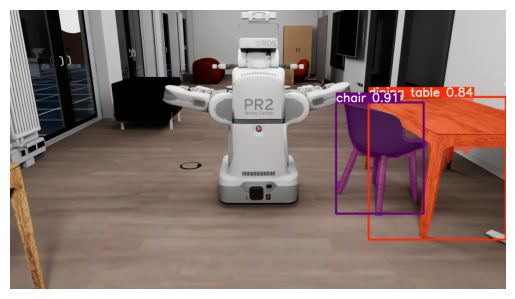

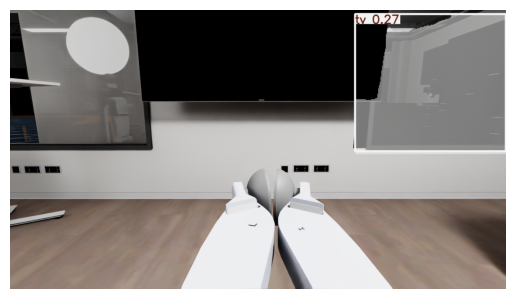

In [19]:
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

yolo_model = YOLO("yolo11n-seg.pt")

if in_notebook:
    image_raw = [
        stretch_head_cam.get_rgba()[:, :, :3],
        stretch_gripper_cam.get_rgba()[:, :, :3],
    ]
    seg_res = yolo_model.predict(image_raw, save=False)
    for res in seg_res:
        plt.imshow(res.plot())
        plt.axis("off")
        plt.show()

## Create ROS subscribers

Listen to messages on topic `cmd_vel`

In [20]:
import rclpy
from rclpy.node import Node
from geometry_msgs.msg import Twist
import numpy as np

if not rclpy.ok():
    rclpy.init(args=None)

class CmdVelController(Node):
    def __init__(self, robot_art):
        super().__init__('cmd_vel_listener')

        # External robot handle
        self.robot_art = robot_art

        # Subscribe to cmd_vel
        self.subscription = self.create_subscription(
            Twist,
            'cmd_vel',
            self.cmd_vel_callback,
            10
        )

        # Stretch parameters
        self.wheel_base = 0.3407
        self.wheel_radius = 0.0125
        self.factor = 0.1


    def cmd_vel_to_wheel_speeds(self, v, w):
        """
        Convert linear (v) and angular (w) velocity into left/right wheel angular speeds.
        Returns wheel speeds in rad/s.
        """
        v_left = v - w * self.wheel_base / 2
        v_right = v + w * self.wheel_base / 2

        return v_left / self.wheel_radius, v_right / self.wheel_radius


    def cmd_vel_callback(self, msg):
        # Convert cmd_vel to wheel velocities
        lv, rv = self.cmd_vel_to_wheel_speeds(
            msg.linear.x,
            msg.angular.z
        )

        next_joint_vel = np.zeros(self.robot_art.num_dof)

        # Wheel joint indices (matching your original code)
        next_joint_vel[1] = max(lv * self.factor, 3)
        next_joint_vel[3] = max(rv * self.factor, 3)

        self.robot_art.set_joint_velocities([next_joint_vel])

cmd_node = CmdVelController(robot_arts["stretch"])

## ROS Publishers

### Camera Sensor Publisher

In [21]:
from sensor_msgs.msg import Image
from rclpy.node import Node
import numpy as np

class CameraPublisher(Node):
    def __init__(self, node_name='camera_publisher', topic="/camera/image_raw"):
        super().__init__(node_name)
        self.pub = self.create_publisher(Image, topic, 10)

    def publish_image(self, rgb_array):
        msg = Image()
        msg.height = rgb_array.shape[0]
        msg.width = rgb_array.shape[1]
        msg.encoding = "rgb8"
        msg.is_bigendian = 0
        msg.step = rgb_array.shape[1] * 3
        msg.data = rgb_array.flatten().tolist()
        self.pub.publish(msg)

head_cam_node = CameraPublisher(node_name="head_cam_node", topic="/head_camera/image_raw")
gripper_cam_node = CameraPublisher(node_name="gripper_cam_node", topic="/gripper_camera/image_raw")

## Open `rviz2` and `rqt_robot_steering`

In [23]:
import subprocess
import os
os.environ.pop("PYTHONPATH", None)
steer_gui = """
source /opt/ros/jazzy/setup.bash
source $DEV_TOOLS_PATH/ros_ws/apartment_ws/install/setup.bash
ros2 run rqt_robot_steering rqt_robot_steering &
rviz2 -d ./camera.rviz
# rviz2 -d ./laser.rviz
"""
cmd = ["bash", "-c", steer_gui]
subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

<Popen: returncode: None args: ['bash', '-c', '\nsource /opt/ros/jazzy/setup...>

## Run the simulation loop with ROS node spinning

Once the simulation loop is running, you can drag the  sliders to control the robot's forward/backward movement and steering.

In [26]:
steps = 1000
desc = "ROS Spin"
bar_format = "{l_bar}{bar}| {n_fmt}/{total_fmt} steps] {elapsed_s:.2f}s"

for i in tqdm(range(steps), desc=desc, ncols=60, bar_format=bar_format, file=sys.stdout):
    my_world.step(render=True)
    # cmd_vel subscriber
    rclpy.spin_once(cmd_node, timeout_sec=0.0)

    # # camera publisher
    # if i % 30 == 0:
    #     image_raw = [
    #         stretch_head_cam.get_rgba()[:, :, :3],
    #         stretch_gripper_cam.get_rgba()[:, :, :3],
    #     ]
    #     seg_res = yolo_model.predict(image_raw, save=False, verbose=False)
    #     head_cam_node.publish_image(seg_res[0].plot())
    #     rclpy.spin_once(head_cam_node, timeout_sec=0.0)
    #     gripper_cam_node.publish_image(seg_res[1].plot())
    #     rclpy.spin_once(gripper_cam_node, timeout_sec=0.0)

ROS Spin: 100%|████████████████████| 1000/1000 steps] 41.79s


## Shutdown

In [31]:
cmd_node.destroy_node()
head_cam_node.destroy_node()
gripper_cam_node.destroy_node()
simulation_app.close()

## Covert notebook to Python script

```
jupyter nbconvert --to python apartment.ipynb
```